# Notebook 01 — Exploratory Data Analysis

We explore the ULB Credit Card Fraud Detection dataset to understand its structure, 
severe class imbalance, and the shape of features that will drive modeling decisions 
in later notebooks.

## Dataset context

The dataset contains 284,807 credit card transactions made by European cardholders 
over two days in September 2013, of which 492 are labeled as fraud (0.172%). It was 
released by the Machine Learning Group at Université Libre de Bruxelles (ULB) as 
part of research on fraud detection with imbalanced classes.

Features `V1` through `V28` are the result of a PCA transformation applied by the 
data providers to protect cardholder privacy — we do not know what the underlying 
variables represent. The two features that were **not** transformed are:

- `Time` — seconds elapsed between each transaction and the first transaction in the dataset
- `Amount` — the transaction amount

The target variable `Class` is 1 for fraud and 0 for legitimate transactions.

## What this notebook produces

This notebook is exploratory only. No cleaned CSV or intermediate artifact is exported — 
feature engineering happens in notebook 03. The output of this notebook is a set of 
observations that motivate the modeling choices in notebooks 03-05.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent visual style across the notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load the dataset
df = pd.read_csv("../data/creditcard.csv")

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
df.head()

Shape: (284807, 31)
Memory: 67.4 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Structure and data quality

Before analyzing the class imbalance, we verify the basics: data types, missing values, 
and duplicates. In a real production setting these checks are the first line of defense 
against silent errors downstream.

In [2]:
# Data types and non-null counts
print("Column types:")
print(df.dtypes.value_counts())
print()

# Missing values
missing = df.isnull().sum().sum()
print(f"Total missing values: {missing}")

# Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Column types:
float64    30
int64       1
Name: count, dtype: int64

Total missing values: 0
Duplicate rows: 1081


### On duplicates

The dataset contains 1,081 rows that are exact duplicates across all 31 columns. Since 
V1-V28 are PCA components of unknown underlying features, two distinct legitimate 
transactions producing identical floating-point values across 30 columns is astronomically 
unlikely. These are almost certainly artifacts of the ingestion or anonymization process 
rather than genuine repeated transactions.

Before deciding whether to drop them, we check how they distribute between fraud and 
non-fraud, since duplicate fraud rows would inflate the effective fraud rate seen by 
any model trained on this data.

In [4]:
# Duplicates by class
dup_mask = df.duplicated(keep=False)  # mark ALL occurrences of duplicated rows
dup_by_class = df[dup_mask].groupby("Class").size()
print("Rows involved in duplication, by class:")
print(dup_by_class)
print()

# Fraud rate in duplicates vs full dataset
fraud_rate_full = df["Class"].mean()
fraud_rate_dup = df[dup_mask]["Class"].mean()
print(f"Fraud rate — full dataset: {fraud_rate_full:.4%}")
print(f"Fraud rate — duplicate rows only: {fraud_rate_dup:.4%}")

Rows involved in duplication, by class:
Class
0    1822
1      32
dtype: int64

Fraud rate — full dataset: 0.1727%
Fraud rate — duplicate rows only: 1.7260%


In [5]:
# How many times each duplicated group is repeated
dup_counts = df[dup_mask].groupby(list(df.columns)).size()
print("Distribution of duplication multiplicity:")
print(dup_counts.value_counts().sort_index())
print()
print(f"Unique 'duplicated' transactions: {len(dup_counts)}")
print(f"Total rows involved: {dup_counts.sum()}")

Distribution of duplication multiplicity:
2     611
3      66
4      81
5      10
6       1
9       2
18      2
Name: count, dtype: int64

Unique 'duplicated' transactions: 773
Total rows involved: 1854


### Decision on duplicates

The multiplicity distribution shows most duplicates are pairs (611 transactions appearing 
2 times), but a small tail includes rows repeated 9 or 18 times. High-multiplicity 
duplicates are more consistent with legitimate recurring transactions (e.g., batched 
micropayments) than with ingestion artifacts. However, the ~10× higher fraud rate in 
duplicated rows (1.73% vs 0.17% baseline) means that keeping duplicates would allow a 
model to overfit to those specific fraud patterns and inflate evaluation metrics.

We drop duplicates for modeling purposes, prioritizing evaluation validity over the 
small amount of information lost. This decision is documented here so it can be revisited 
if downstream results depend on it.

In [6]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape}")
print(f"Fraud count: {df['Class'].sum()}")
print(f"Fraud rate: {df['Class'].mean():.4%}")

Shape after dropping duplicates: (283726, 31)
Fraud count: 473
Fraud rate: 0.1667%


## Class imbalance

With 473 fraud cases out of 283,726 transactions (0.167%), this is a severely imbalanced 
classification problem. Two consequences follow immediately:

1. **Accuracy is misleading.** A trivial model that predicts "not fraud" for every 
transaction achieves 99.83% accuracy while catching zero frauds — the metric rewards 
ignoring the problem.

2. **The choice of evaluation metric drives everything downstream.** Precision, recall, 
F1, and the precision-recall curve are the appropriate metrics here; ROC-AUC is 
often reported but can be optimistically biased on severely imbalanced data, because 
the ROC space is dominated by the majority class.

We visualize the imbalance and confirm the accuracy trap numerically before moving on.

In [7]:
# Class distribution
class_counts = df["Class"].value_counts()
print("Class distribution:")
print(class_counts)
print(f"\nImbalance ratio: 1 fraud per {class_counts[0] / class_counts[1]:.0f} legitimate transactions")

# Accuracy of trivial "always predict 0" model
trivial_accuracy = (df["Class"] == 0).mean()
print(f"\nAccuracy of trivial 'always not-fraud' model: {trivial_accuracy:.4%}")
print("Frauds caught by this trivial model: 0")

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Imbalance ratio: 1 fraud per 599 legitimate transactions

Accuracy of trivial 'always not-fraud' model: 99.8333%
Frauds caught by this trivial model: 0


/tmp/ipykernel_33713/2284060912.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, ax=axes[0], palette=["steelblue", "firebrick"])
/tmp/ipykernel_33713/2284060912.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Not fraud (0)", "Fraud (1)"])
/tmp/ipykernel_33713/2284060912.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, ax=axes[1], palette=["steelblue", "firebrick"])
/tmp/ipykernel_33713/2284060912.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator

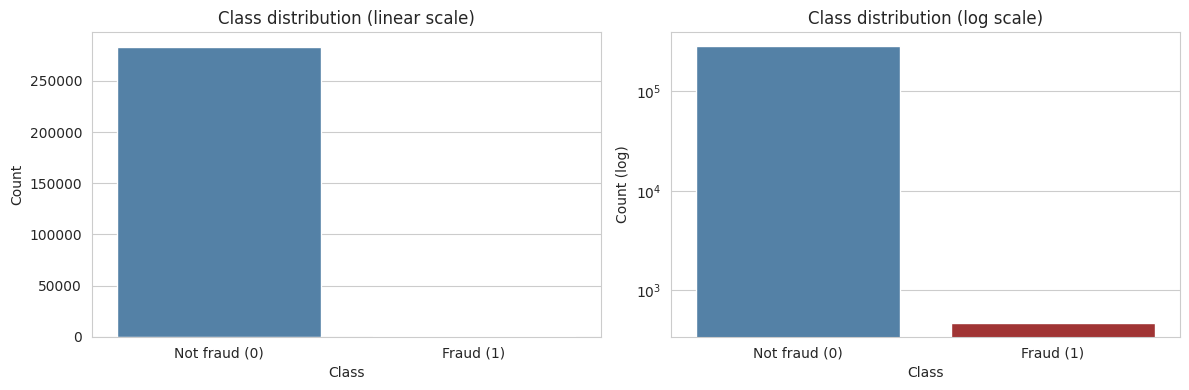

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: linear scale (shows how invisible fraud is)
sns.countplot(x="Class", data=df, ax=axes[0], palette=["steelblue", "firebrick"])
axes[0].set_title("Class distribution (linear scale)")
axes[0].set_xticklabels(["Not fraud (0)", "Fraud (1)"])
axes[0].set_ylabel("Count")

# Right: log scale (makes fraud visible)
sns.countplot(x="Class", data=df, ax=axes[1], palette=["steelblue", "firebrick"])
axes[1].set_yscale("log")
axes[1].set_title("Class distribution (log scale)")
axes[1].set_xticklabels(["Not fraud (0)", "Fraud (1)"])
axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.show()

## The `Time` feature

`Time` is not a timestamp — it is the number of seconds elapsed between each transaction 
and the first transaction in the dataset. The full range therefore spans exactly two days 
of activity.

Two questions matter for modeling:

1. Does fraud concentrate at particular times of day (e.g., overnight when card owners 
are less likely to notice)?
2. Is the overall transaction volume itself informative — do fraud rates change during 
low-activity periods?

In [11]:
# Convert Time (seconds) to hours since the first transaction
df["Hour"] = df["Time"] / 3600

print(f"Time range: {df['Hour'].min():.2f} to {df['Hour'].max():.2f} hours")
print(f"Total span: {df['Hour'].max() / 24:.2f} days")

Time range: 0.00 to 48.00 hours
Total span: 2.00 days


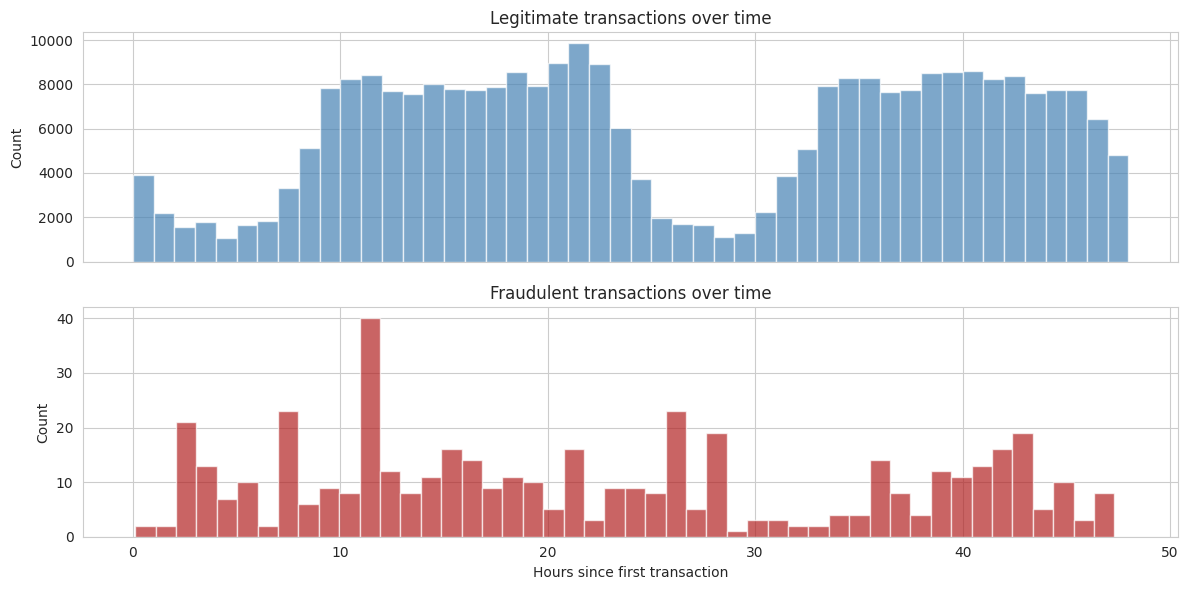

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# All transactions
axes[0].hist(df[df["Class"] == 0]["Hour"], bins=48, color="steelblue", alpha=0.7)
axes[0].set_title("Legitimate transactions over time")
axes[0].set_ylabel("Count")

# Fraud transactions
axes[1].hist(df[df["Class"] == 1]["Hour"], bins=48, color="firebrick", alpha=0.7)
axes[1].set_title("Fraudulent transactions over time")
axes[1].set_xlabel("Hours since first transaction")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [15]:
# Verify claim before writing it in the markdown
fraud_by_hour = df[df["Class"] == 1]["Hour"].astype(int).value_counts().sort_values(ascending=False)
legit_by_hour = df[df["Class"] == 0]["Hour"].astype(int).value_counts()

print("Top 5 fraud hours:")
print(fraud_by_hour.head())
print("\nLow-activity hours (fewer than 4000 legit transactions):")
low_activity = legit_by_hour[legit_by_hour < 4000].sort_index()
print(low_activity)

Top 5 fraud hours:
Hour
11    43
26    27
7     23
2     21
42    18
Name: count, dtype: int64

Low-activity hours (fewer than 4000 legit transactions):
Hour
0     3929
1     2211
2     1552
3     1805
4     1076
5     1668
6     1819
7     3343
24    3712
25    1987
26    1708
27    1665
28    1105
29    1309
30    2254
31    3867
Name: count, dtype: int64


### Observations on `Time`

Legitimate transactions show the expected day/night activity pattern with two clear 
cycles across the 48-hour span, with 16 hours (two overnight periods of 8 hours each) 
where legitimate volume falls below 4,000 per hour. Of the 5 hours with the most fraud, 
3 fall in these low-activity windows (hours 2, 7, 26) while the two highest fraud counts 
occur during peak legitimate activity (hour 11 with 43 cases, hour 42 with 18). With 
only ~10 fraud cases per hour on average, the temporal pattern is too weak to draw 
firm conclusions. 

`Time` remains a usable feature for modeling.